# Project 6.3.: Customer segmentation with clustering

## Initial data pre-processing

### Import libraries and data set

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import dendrogram, linkage

data = pd.read_csv('https://github.com/FourthRevGitHub/CAM_DS_Public-Data-Sets/raw/main/Course%201/Week%206/CUSTOMERS_CLEAN.zip')

### Viewing and pre-processing the data

In [ ]:
# Initial Data overview for context
print("Rows, columns:", data.shape)
display(data.head())

display(data.info())

# Missing values
missing_counts = data.isna().sum()
missing_percent = (missing_counts / len(data) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

display(missing_summary[missing_summary["missing_count"] > 0])

# Duplicate rows
duplicate_count = data.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Basic numeric summary
numeric_summary = data.describe(include=["number"]).T
numeric_summary["missing"] = data.select_dtypes(include=["number"]).isna().sum()

display(numeric_summary)

Rows, columns: (951669, 20)


,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951669 entries, 0 to 951668
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Quantity              951669 non-null  int64 
 1   City                  951534 non-null  object
 2   Continent             951669 non-null  object
 3   Postal_Code           947953 non-null  object
 4   State_Province        834477 non-null  object
 5   Order_Date            951669 non-null  object
 6   Delivery_Date         951669 non-null  object
 7   Total Revenue         951669 non-null  object
 8   Unit Cost             951669 non-null  object
 9   Discount              951669 non-null  object
 10  OrderTypeLabel        951669 non-null  object
 11  CustomerCountryLabel  951669 non-null  object
 12  Customer_BirthDate    951669 non-null  object
 13  Customer_Group        951669 non-null  object
 14  Customer_Type         951669 non-null  object
 15  Order ID         

None

,missing_count,missing_percent
City,135,0.01
Postal_Code,3716,0.39
State_Province,117192,12.31


Duplicate rows: 21


,count,mean,std,min,25%,50%,75%,max,missing
Quantity,951669.0,1.678438e+00,8.999142e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+01,0
Order ID,951669.0,1.236943e+09,4.273202e+06,1.230000e+09,1.233081e+09,1.236755e+09,1.240689e+09,1.244338e+09,0
Days to Delivery,951669.0,1.056107e+00,2.065725e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.200000e+01,0
Loyalty Num,951669.0,6.653408e+01,4.647679e+01,0.000000e+00,0.000000e+00,9.900000e+01,9.900000e+01,9.900000e+01,0
Customer ID,951669.0,4.544060e+04,2.721415e+04,1.000000e+00,2.213900e+04,4.414000e+04,7.041100e+04,9.425400e+04,0


In [ ]:
# Remove all duplicate rows from the DataFrame
data = data.drop_duplicates()

We are interested not in each of the almost 1 million rows, but instead in the customers themselves. Therefore we must aggregate orders by customer to create new features of frequency, recency, CLV, average unit cost, and customer age.

### Feature Engineering

In [ ]:
# Step 1: Convert order, delivery, and birth dates into datetime format
data['Order_Date'] = pd.to_datetime(data['Order_Date'], format='%d%b%Y')
data['Delivery_Date'] = pd.to_datetime(data['Delivery_Date'], format='%d%b%Y')

# Convert customer birth date to datetime
data['DOB'] = pd.to_datetime(data['Customer_BirthDate'], format='%d%b%Y')

# Compute customer age using the most recent order date as reference
reference_date = data['Order_Date'].max()
data['Age'] = (reference_date - data['DOB']).dt.days // 365

# Step 2: Convert monetary columns from strings to numeric values
# Helper function to clean and parse currency-formatted values
def currency_to_float(x):
    if isinstance(x, str):
        # Identify negative amounts represented with parentheses
        is_negative = '(' in x and ')' in x

        # Strip currency symbols, thousand separators, and parentheses
        x = x.replace('$', '').replace(',', '').replace('(', '').replace(')', '')

        value = float(x)
        return -value if is_negative else value

    return float(x)

data['CLV'] = data['Total Revenue'].apply(currency_to_float)
data['Avg_Unit_Cost'] = data['Unit Cost'].apply(currency_to_float)

# Derive purchase frequency per customer
data['Frequency'] = data.groupby('Customer ID')['Order ID'].transform('count')

# Derive recency as days since the most recent order
# (relative to the latest order date in the dataset)
data['Recency'] = (reference_date - data['Order_Date']).dt.days

data[['Frequency', 'Recency']].head()

# Create a customer-level dataset (one row per customer)
data_selected = data[['Customer ID', 'Frequency', 'Recency', 'CLV', 'Avg_Unit_Cost', 'Age']]

customer_data_full = data_selected.groupby('Customer ID').agg({
    'Frequency': 'max',        # total number of purchases
    'Recency': 'min',          # most recent purchase (in days)
    'CLV': 'sum',              # total customer revenue
    'Avg_Unit_Cost': 'mean',   # average unit cost
    'Age': 'max'               # customer age
}).reset_index()

# Keep a dedicated 10k sample only for computationally expensive methods
customer_data_sample_10k = customer_data_full.sample(n=10000, random_state=42)


I keep the full customer-level dataset for EDA and core clustering outputs, and use the fixed 10,000 row sample only for computationally expensive steps (Dendrogram and t-SNE). This may lead to mildy skewed outputs, but really shouldn't make too much of a difference in accuracy in conclusions and insights

In [ ]:
# Sense check to ensure both datasets were created properly
print("Full customer-level dataset shape:", customer_data_full.shape)
print("10k sample dataset shape:", customer_data_sample_10k.shape)
customer_data_full.head()

Full customer-level dataset shape: (68300, 6)
10k sample dataset shape: (10000, 6)


,Customer ID,Frequency,Recency,CLV,Avg_Unit_Cost,Age
0,1,35,17,4322.70,89.622857,63
1,3,20,124,2821.00,90.505000,33
2,4,9,1108,782.67,37.195556,33
3,5,19,5,2810.98,107.947368,28
4,6,15,192,1604.58,52.526667,58


## EDA

### Exploring data shape, data types, duplicates, missing values, and descriptive stats


In [ ]:
# View shape of the full customer dataset
print("Shape of customer_data_full:", customer_data_full.shape)

# Check data types of each column
print("\nData types:\n", customer_data_full.dtypes)

# Check for duplicate customers
duplicate_customers = customer_data_full.duplicated(subset=['Customer ID']).sum()
print(f"\nNumber of duplicate Customer IDs: {duplicate_customers}")

# Check for missing values
missing_counts = customer_data_full.isnull().sum()
print("\nMissing values in each column:\n", missing_counts)

# Show basic descriptive statistics for numeric columns
print("\nDescriptive statistics:")
print(customer_data_full.describe())

Shape of customer_data_full: (68300, 6)

Data types:
 Customer ID        int64
Frequency          int64
Recency            int64
CLV              float64
Avg_Unit_Cost    float64
Age                int64
dtype: object

Number of duplicate Customer IDs: 0

Missing values in each column:
 Customer ID      0
Frequency        0
Recency          0
CLV              0
Avg_Unit_Cost    0
Age              0
dtype: int64

Descriptive statistics:
        Customer ID     Frequency       Recency           CLV  Avg_Unit_Cost  \
count  68300.000000  68300.000000  68300.000000  68300.000000   68300.000000   
mean   45447.623397     13.933353    367.662167   1950.148420      78.895675   
std    27203.855105     11.328807    414.511202   1719.916365      38.005259   
min        1.000000      1.000000      0.000000      0.630000       0.500000   
25%    22160.500000      6.000000     45.000000    696.000000      57.579792   
50%    44140.500000     11.000000    190.000000   1497.400000      73.450000   


### Visualisation & outlier check

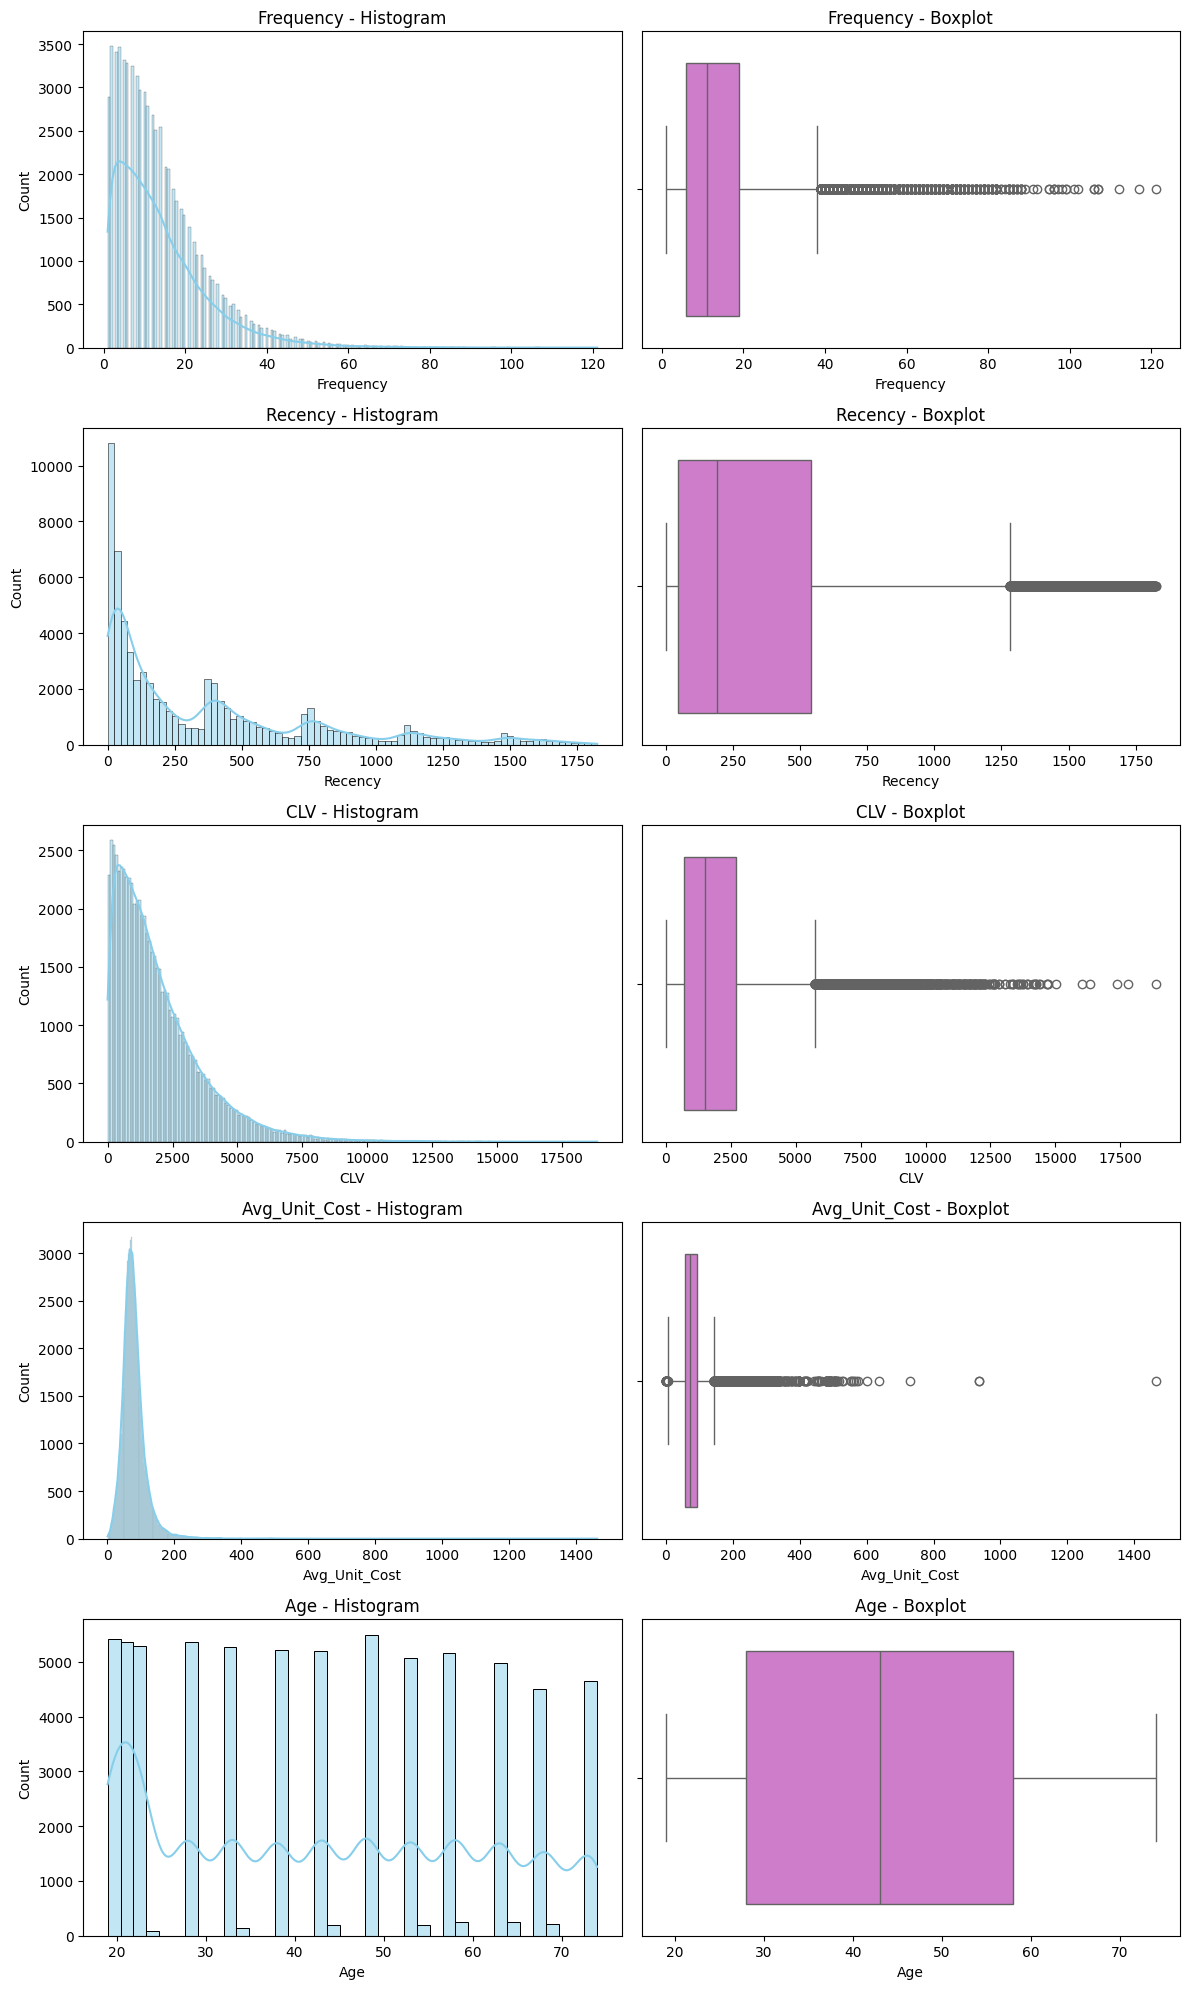

Number and percent of outliers in each numeric column (based on IQR):
Frequency: 2654 outliers (3.89%)
Recency: 3361 outliers (4.92%)
CLV: 2590 outliers (3.79%)
Avg_Unit_Cost: 2889 outliers (4.23%)
Age: 0 outliers (0.00%)


In [ ]:
# Visualising the full dataset through box plots and histograms
numeric_cols = ['Frequency', 'Recency', 'CLV', 'Avg_Unit_Cost', 'Age']

# Set up the matplotlib figure
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 20))

for i, col in enumerate(numeric_cols):
    # Histogram
    sns.histplot(customer_data_full[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=customer_data_full[col], ax=axes[i, 1], color='orchid')
    axes[i, 1].set_title(f'{col} - Boxplot')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()

# Check out the number of outliers for each numeric column based on the IQR
print("Number and percent of outliers in each numeric column (based on IQR):")
for col in numeric_cols:
    Q1 = customer_data_full[col].quantile(0.25)
    Q3 = customer_data_full[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = customer_data_full[(customer_data_full[col] < lower_bound) | (customer_data_full[col] > upper_bound)]
    num_outliers = outliers.shape[0]
    percent_outliers = 100 * num_outliers / customer_data_full.shape[0]
    print(f"{col}: {num_outliers} outliers ({percent_outliers:.2f}%)")

Frequency: Histogram shows log-like distribution with most customers make 1–40 purchases; a small number exceed 120+, producing many box-plot outliers.

Recency: Log-like distribution but  with distinct spikes, suggesting seasonality (e.g. promotions or holidays). IQR flags outliers, but these are retained as they likely matter for clustering.

Customer Lifetime Value (CLV): Logarithmic distribution with a few extremely high values, resulting in many box-plot outliers.

Average Unit Cost: Roughly bell-shaped with a long right tail; box plot is very tight with numerous high-price outliers.

Age: Box plot shows a wide IQR and an overall range from roughly 18 to 70+ years.

## Clustering

### Ideal # of clusters determination methods

#### Elbow method

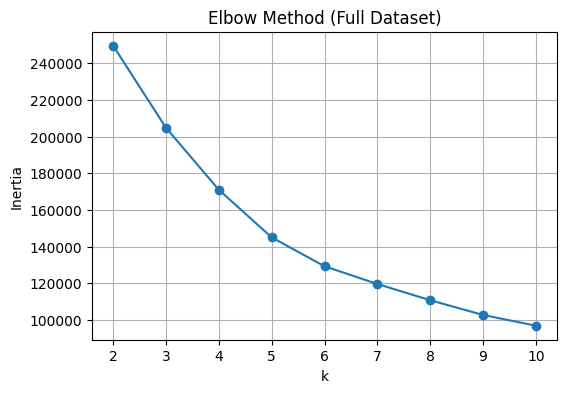

In [ ]:
# K-means clustering setup (scaled numeric features)
feature_cols = customer_data_full.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col != "Customer ID"]

# Full dataset path
X_full = customer_data_full[feature_cols].copy()
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_full)

# 10k sampled path (when needed for expensive methods)
X_sample_10k = customer_data_sample_10k[feature_cols].copy()
scaler_sample = StandardScaler()
X_scaled_sample = scaler_sample.fit_transform(X_sample_10k)

# Elbow method on full data
X_for_model_selection = X_scaled_full

k_values = range(2, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_for_model_selection)
    inertias.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
})
elbow_df

plt.figure(figsize=(6, 4))
plt.plot(elbow_df["k"], elbow_df["inertia"], marker="o")
plt.title("Elbow Method (Full Dataset)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

We can see that the steepest slope in the elbow method graph is between 2 & 3, and progressively becomes less steep as we increase cluster numbers. Due to this very gradual decrease, as opposed to a closer to right angle shape of the line, something between 3–6 could be an appropriate number of clusters. We will use this range for the silhouette scores to use another method to check for the best number of clusters.

#### Silhouette Method

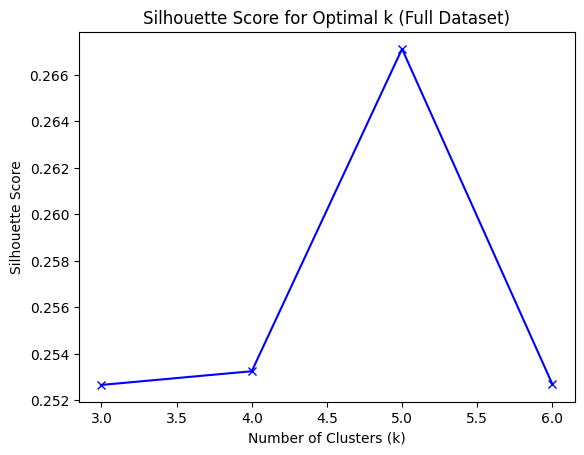

In [ ]:
# Silhouette scores by k (full data set)
silhouette_k_values = range(3, 7)
silhouettes = []

for k in silhouette_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_for_model_selection)
    silhouettes.append(silhouette_score(X_for_model_selection, labels))

silhouette_df = pd.DataFrame({
    "k": list(silhouette_k_values),
    "silhouette": silhouettes,
})
silhouette_df

plt.plot(silhouette_k_values, silhouettes, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k (Full Dataset)')
plt.show()

The silhouette score is best at 5, indicating 5 is the best amount of clusters based on this data. However, we must remember that the scores are all quite low around the .25-.27 mark. This is a low cluster score, and therefore means weak evidence for choosing 5, even though it is definitely the highest.

#### Dendogram

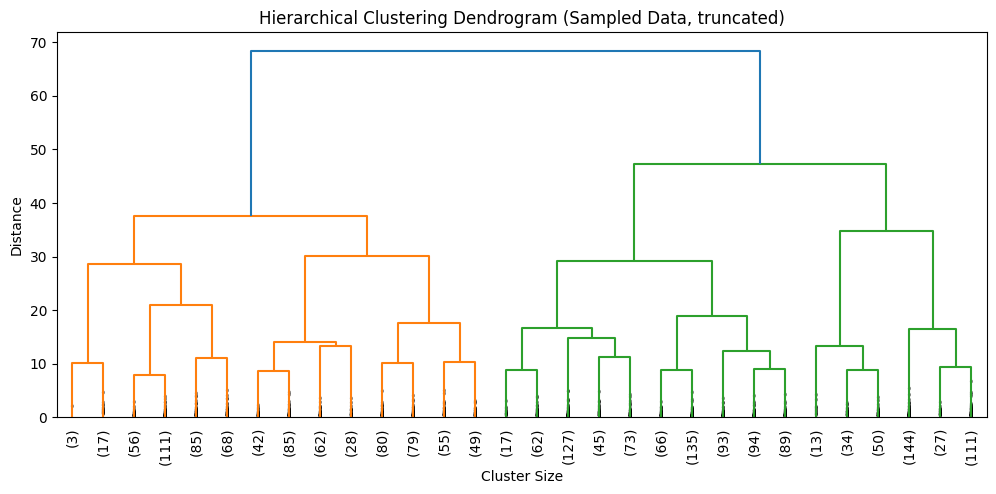

In [ ]:
# Dendrogram uses exactly 2,000 points from the 10k sampled dataset
sample_size = 2000

rng = np.random.RandomState(42)
sample_idx = rng.choice(X_scaled_sample.shape[0], size=sample_size, replace=False)
X_dendrogram = X_scaled_sample[sample_idx]

# Build hierarchical clustering structure
linked = linkage(X_dendrogram, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
)
plt.title("Hierarchical Clustering Dendrogram (Sampled Data, truncated)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

If we look at the graph, we see 2 long vertical lines (representing 2 clusters) if we draw our horizontal line at 60. This would be a strong point to say there are "enough" clusters now, however based on our past analysis in the elbow method, we concluded 2 is too few. There are 3 relatively long lines if the horizontal line is at 45; this could be a strong option. If we move to a line at 34 and 32, this intercepts 4 & 5 lines/clusters respectively; the orange lines are quite short, showing not a strong grouping, but all 2/3 green lines have long vertical lines, especially at 34, suggesting strong clusters. From the dendrogram and previous analysis, between 3–5 clusters is currently our best estimate of the ideal cluster count.

Based on all three clustering methods, 3–5 is an acceptable range of choices. However, since in the silhouette score we saw 5 have the highest score, I will choose this as the optimal number of k, even though others are relatively similar in quality.

## Performing k-means on 5 clusters

In [ ]:
# Perform k-means with 5 clusters on the full dataset
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_full = kmeans_5.fit_predict(X_scaled_full)

# Attach cluster labels to the full customer dataset
customer_data_clustered_full = customer_data_full.copy()
customer_data_clustered_full["Cluster"] = cluster_labels_full

# Quick check of cluster sizes and preview
display(customer_data_clustered_full[["Customer ID", "Cluster"]].head())
print("Cluster counts (full dataset):\n", customer_data_clustered_full["Cluster"].value_counts().sort_index())

# Using k=5 and listing the labels
print(cluster_labels_full)

,Customer ID,Cluster
0,1,2
1,3,1
2,4,4
3,5,1
4,6,0


Cluster counts (full dataset):
 Cluster
0    20186
1    22580
2    11225
3     3714
4    10595
Name: count, dtype: int64
[2 1 4 ... 2 0 4]


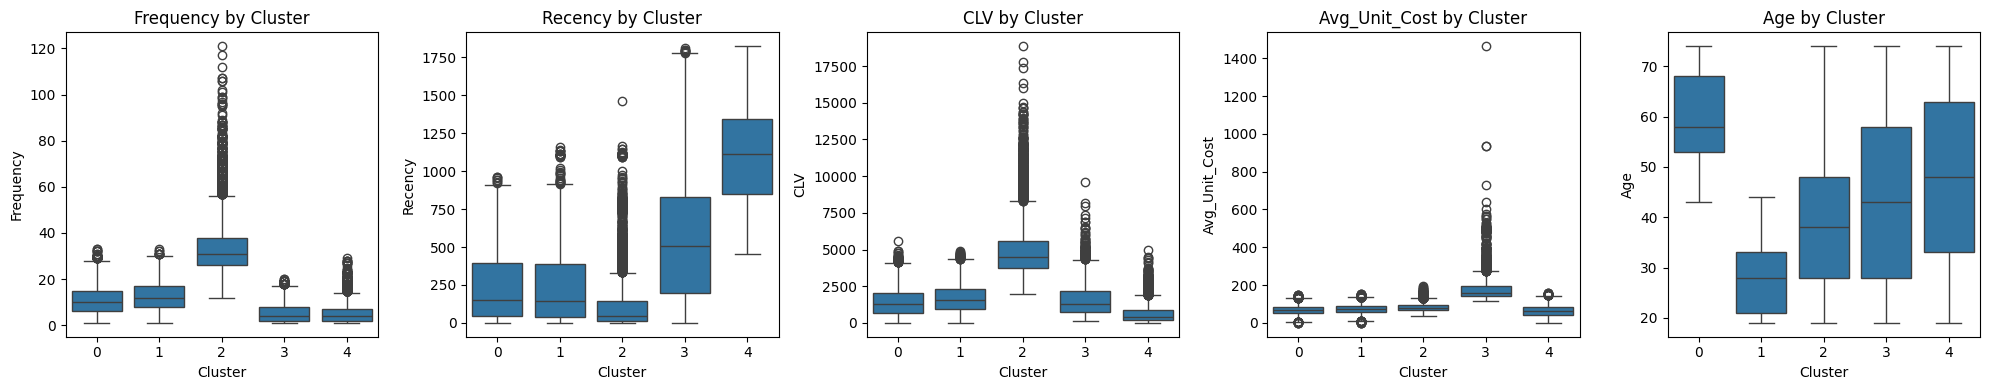

Frequency            Recency                  CLV               \
           median        std  median         std   median          std   
Cluster                                                                  
0            10.0   6.151176   150.0  212.148661  1273.34   910.715068   
1            12.0   6.082370   142.0  225.119903  1581.53   905.251998   
2            31.0  11.371713    44.0  177.296618  4481.59  1694.967619   
3             4.0   3.804774   508.5  432.567932  1277.40  1149.375218   
4             4.0   3.932721  1111.0  308.353676   429.30   582.766886   

        Avg_Unit_Cost               Age             
               median        std median        std  
Cluster                                             
0           69.277500  24.068501   58.0   8.910759  
1           72.073252  23.651704   28.0   7.968075  
2           80.094545  19.157904   38.0  14.398524  
3          161.041667  68.731125   43.0  17.242457  
4           61.166667  29.387183   48.0  17.558077

In [ ]:
# Visualise the k=5 clusters (full dataset)
metrics = ["Frequency", "Recency", "CLV", "Avg_Unit_Cost", "Age"]

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4), sharex=True)

for ax, metric in zip(axes, metrics):
    sns.boxplot(data=customer_data_clustered_full, x="Cluster", y=metric, ax=ax)
    ax.set_title(f"{metric} by Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

# Summary table: median and standard deviation by cluster
cluster_summary = customer_data_clustered_full.groupby("Cluster")[metrics].agg(["median", "std"])
cluster_summary

Cluster 0
- Frequency: moderate at 10 times
- Recency: moderate, with a similar spread to cluster 0
- CLV: moderate, with fewer extreme outliers
- Average unit cost: little separation from clusters 0 and 1
- Age: significantly older on average

Cluster 1
- Frequency: moderate at 12 times, with most customers purchasing fewer than 20 times
- Recency: generally low, indicating relatively recent purchases
- CLV: mid-range, with a couple higher-value outliers
- Average unit cost: little variation and similar to most other clusters
- Age: significantly younger average compared to other clusters

Cluster 2
- Frequency: highest across all clusters, many high outliers
- Recency: lowest, indicating very recent purchasing behaviour
- CLV: highest, with a wide distribution and several high-value outliers
- Average unit cost: Marginally higher median, significantly lower SD but outliers with high AUC
- Age: around the mid-range compared to other clusters, but large IQR

Cluster 3
- Frequency: tied lowest # of purchases at 4 times
- Recency: relatively high, indicating less recent purchasing activity
- CLV: moderate, with some higher-value outliers
- Average unit cost: highest and with high cost outliers
- Age: broad distribution, skewing slightly older on average

Cluster 4
- Frequency: low, with most customers purchasing only a few times, but some outliers
- Recency: high, indicating many days since last purchase
- CLV: lowest among all clusters
- Average unit cost: no meaningful difference from clusters 0 and 1
- Age: skews older on average, but a wide range of ages

More analysis will be done on these in the report, including interpreting the characteristics for each cluster to create customer "types" which can be turned into actionable business targets.


## PCA & t-SNE

In [ ]:
# Perform PCA to reduce dimensions to 2D (full scaled data)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_full)

# Store PCA results with cluster labels for later visualization
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = customer_data_clustered_full["Cluster"].values

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.44534391 0.20728245]
Total explained variance: 0.6526263530012631


In [ ]:
# Perform t-SNE to reduce dimensions to 2D (sampled scaled data)
# Perplexity at 30 for first try to see if produces graph with pattern
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(X_scaled_sample)

# Use the fitted full-data k-means model to label the sampled points
sample_cluster_labels = kmeans_5.predict(X_scaled_sample)

# Store t-SNE results with cluster labels for later visualization
tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["Cluster"] = sample_cluster_labels

print("t-SNE output shape (sampled):", X_tsne.shape)

t-SNE output shape (sampled): (10000, 2)


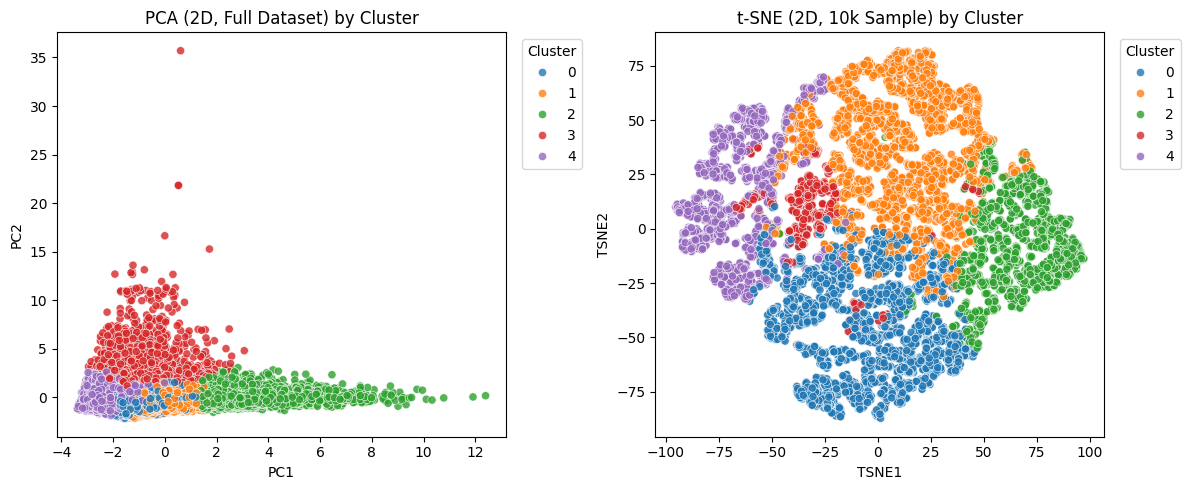

In [ ]:
# Visualisation of both PCA & t-SNE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=35,
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title("PCA (2D, Full Dataset) by Cluster")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Cluster",
    palette="tab10",
    s=35,
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title("t-SNE (2D, 10k Sample) by Cluster")
axes[1].set_xlabel("TSNE1")
axes[1].set_ylabel("TSNE2")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

PCA: Explained variance at .65 is a acceptable result, meaning the two components make up a significant proportion of the variance in the data. Regarding the graph, we can see clusters created through each color. The first obvious interpretation is that we see a large overlap region for each cluster, especially for clusters 0, 1 & 4. Cluster 2 has some overlap but covers a large portion of the width on PC1, and cluster 3 covers a large range of height on PC2.

t-SNE: Clusters appear pretty well grouped, with significant overlap mainly only happening for cluster 3. Each other component occupies a pretty distinct region in the graph.

# Interpretation & Reflection

The approach to this project was straightforward. Initial steps included pre-processing to eliminate duplicates. Since we were interested in looking not at information by order, but by customer, I organized the data by five salient features per customer.

After understanding the distribution and box plot information of each of these features, I began to look at clustering. To determine the ideal number of clusters, I used three methods. Utilizing the elbow method, I graphed inertia scores across 2-10 clusters to determine an appropriate cluster range, and the results led me to think that three to six clusters were an appropriate amount. The second method was an examination of silhouette scores. While the silhouette scores weren't very high, meaning that the results weren't very strongly indicative of better and worse clustering, five had the highest. Finally, I used a dendrogram where the long lines showed an appropriate number of clusters from anywhere between two and five clusters. Based on these three tests, I selected five clusters for further data analysis.

After plotting a boxplot for each of the five variables with data by cluster, I was able to take clear learnings about the characteristics of each cluster, aka customer group. I then used PCA and t-SNE to check whether the clusters showed clear signs of grouping together, or whether there was a lot of overlap, meaning low confidence that customers within clusters act in similar ways. Based on both PCA and t-SNE, we can be reasonably confident that customers within clusters do act in similar ways, and therefore our customer groupings can be used for the business.

I will go deeper into detail on both approach and effectiveness of each method in the report.

### Reference:
SAS, 2024. CUSTOMERS_CLEAN [Data set]. SAS. Last revised on 15 December 2021. [Accessed 20 February 2024].